# Market Data Foundations for Financial Engineering

This notebook treats Python as a practical engine for collecting, structuring, validating, and interpreting market data for professional financial analysis.

The goal is not to learn syntax. The goal is to understand the workflow that turns raw market data into a reliable analytical base for monitoring, comparison, risk analysis, and later modeling work.

**Roadmap**
- Frame the financial question
- Define the market universe and data requirements
- Collect market data programmatically
- Audit data quality and consistency
- Build a canonical price table
- Derive finance-ready metrics
- Visualize performance and risk
- Produce an analyst summary table
- Explain downstream uses
        


## B. Why this matters in professional finance

**Financial purpose.** Before any valuation, dashboard, risk report, or trading idea can be trusted, the underlying market data must be consistent and economically interpretable.

In finance, weak data treatment leads directly to weak conclusions.

- Inconsistent prices create misleading cross-asset comparisons.
- Missing dates or misaligned calendars can distort returns and volatility.
- Using the wrong price field can embed dividend or corporate-action noise into the analysis.
- Any later model, dashboard, valuation screen, or trading signal is only as reliable as the dataset underneath it.

That is why this first Python session is not about programming tricks. It is about building a market-data foundation that can actually support professional work.
        


## C. Define the market universe and analytical objective

**Financial purpose.** A market-data workflow starts by deciding which assets deserve comparison and which benchmark will anchor the analysis.

We use a deliberately small but financially meaningful US equity universe:

- **SPY**: broad equity benchmark for the US market
- **MSFT**: mega-cap technology / growth exposure
- **JNJ**: defensive healthcare exposure
- **CAT**: cyclical industrial exposure

This mix is useful because it supports multiple types of comparison at once: benchmarking, style contrast, sector contrast, and relative risk behavior.

**Financial question for the session**

> How do we turn daily market data for a benchmark and a few representative assets into a consistent analytical base that can support monitoring, peer comparison, and later modeling work?

We fix the analysis window to **2022-01-01 through 2025-12-31** and use **daily frequency**. A fixed window keeps the classroom case reproducible, while daily data is the natural starting point for returns, volatility, drawdowns, and correlation analysis.
        


In [1]:
# Import system utilities so the notebook can locate repository files reliably.
import sys
import io
import contextlib
from pathlib import Path

# Import the numerical and tabular libraries used for financial data handling.
import numpy as np
import pandas as pd

# Import plotting tools for finance-oriented visual analysis.
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Import the market-data connector used for programmatic download from Yahoo Finance.
import yfinance as yf

# Use rich notebook display when available so tables and markdown render cleanly.
try:
    from IPython.display import Markdown, display
except ImportError:
    # Fallback display helpers keep the notebook executable even outside Jupyter.
    def display(obj):
        print(obj)

    def Markdown(text):
        return text

# Detect the repository root so data and cache files are found from any launch location.
PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()

# Add the project root to the Python path if it is not already present.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Format numeric tables with a fixed number of decimals for cleaner classroom reading.
pd.options.display.float_format = "{:,.4f}".format

# Use a consistent plotting style so charts look professional and comparable across sections.
plt.style.use("seaborn-v0_8-whitegrid")

# Define a restrained color palette used throughout the notebook.
COLORS = {
    "navy": "#14324A",
    "teal": "#1F6F78",
    "sand": "#D7C3A3",
    "slate": "#5A6C7D",
    "green": "#2D7D46",
    "red": "#A6473C",
}

# Make the market universe explicit so the analytical perimeter is visible from the start.
TICKERS = ["SPY", "MSFT", "JNJ", "CAT"]

# Set the benchmark explicitly because later relative metrics depend on it.
BENCHMARK = "SPY"

# Fix the start date so the classroom case is reproducible.
START_DATE = "2022-01-01"

# Fix the end date so every student sees the same sample window.
END_DATE = "2025-12-31"

# Define a cache file that can support classroom use if the live download is unavailable.
CACHE_PATH = PROJECT_ROOT / "data" / "market_data_foundations_prices.csv"

# Create a compact universe table so the choice of assets is justified, not arbitrary.
market_universe = pd.DataFrame(
    {
        "Ticker": ["SPY", "MSFT", "JNJ", "CAT"],
        "Role in analysis": [
            "Benchmark",
            "Large-cap growth / technology",
            "Defensive healthcare",
            "Cyclical industrial",
        ],
        "Why it is included": [
            "Reference market performance and benchmark correlation",
            "Represents higher-growth, lower-dividend equity behavior",
            "Represents more defensive equity behavior",
            "Represents more cyclical, economically sensitive behavior",
        ],
    }
)

# Format a decimal as a percentage because summary tables are easier to read that way.
def pct(value):
    return f"{value * 100:.2f}%"


# Remove the top and right spines so charts emphasize the data instead of the frame.
def style_axes(axis):
    axis.spines[["top", "right"]].set_visible(False)


# Build a robust download function that prefers live data but can fall back to the cached classroom file.
def load_market_data(tickers, start_date, end_date, cache_path):
    # Silence the raw download output so the classroom notebook stays clean if Yahoo Finance is unavailable.
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        # Request the full OHLCV structure plus adjusted prices.
        raw = yf.download(
            tickers=tickers,
            start=start_date,
            end=end_date,
            auto_adjust=False,
            progress=False,
            threads=False,
        )

    # If the download succeeds, refresh the local cache so later runs remain reproducible.
    if raw is not None and not raw.empty:
        raw.to_csv(cache_path)
        return raw, "Yahoo Finance live download"

    # If the live request fails, use the cached classroom dataset instead.
    if cache_path.exists():
        cached = pd.read_csv(cache_path, header=[0, 1], index_col=0, parse_dates=True)
        return cached, f"Local cache fallback ({cache_path.name})"

    # If neither source works, stop the workflow because downstream analysis would be unreliable.
    raise ValueError("No market data available. Check internet access or provide the cache file.")


# Convert full-sample daily returns into annualized returns for cross-asset comparison.
def annualized_return(return_table, trading_days=252):
    return (1 + return_table).prod() ** (trading_days / len(return_table)) - 1


# Convert daily volatility into annualized volatility using the standard square-root-of-time convention.
def annualized_volatility(return_table, trading_days=252):
    return return_table.std() * np.sqrt(trading_days)


# Show the universe table before any download so students see the analytical setup clearly.
display(market_universe)


,Ticker,Role in analysis,Why it is included
0,SPY,Benchmark,Reference market performance and benchmark cor...
1,MSFT,Large-cap growth / technology,"Represents higher-growth, lower-dividend equit..."
2,JNJ,Defensive healthcare,Represents more defensive equity behavior
3,CAT,Cyclical industrial,"Represents more cyclical, economically sensiti..."


## D. Programmatic data collection

**Financial purpose.** The analyst needs a repeatable market-data intake process, not a manual spreadsheet exercise.

With the universe defined, the first operational step is to collect the raw market data in a reproducible way.

**What are we doing?** We request daily OHLCV data and adjusted prices for the chosen universe over the fixed analysis window.

**Why does it matter?** A professional workflow should be refreshable. The analyst should not need to manually copy prices into a spreadsheet every time the universe or date range changes.

**What does this output allow us to do next?** It gives us the raw market-data object that we can audit before deciding which fields are trustworthy enough to use downstream.
        


In [2]:
# Functional step: bring the chosen market universe into the notebook through a repeatable intake process.
# Financial purpose: professional analysis should start from refreshable market data, not from manual copy-paste.
# Load the raw market dataset through the reproducible workflow defined above.
raw, data_source = load_market_data(TICKERS, START_DATE, END_DATE, CACHE_PATH)

# Sort the index so dates are always in chronological order before auditing or analysis.
raw = raw.sort_index()

# Report the source so students know whether the run came from live data or the local classroom cache.
print(f"Data source used in this run: {data_source}")

# Show the raw matrix size to make the scale of the download explicit.
print(f"Rows x columns: {raw.shape}")

# Show the raw date range returned by the connector.
print(f"Date range returned: {raw.index.min().date()} to {raw.index.max().date()}")

# List the available fields because price-field choice is a finance decision, not a coding detail.
print(f"Available price fields: {list(raw.columns.get_level_values(0).unique())}")

# Display only the first few rows because we just need to confirm the raw structure, not explore endlessly.
display(raw.head(3))


Data source used in this run: Yahoo Finance live download
Rows x columns: (1002, 24)
Date range returned: 2022-01-03 to 2025-12-30
Available price fields: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


Price      Adj Close                               Close                    \
Ticker           CAT      JNJ     MSFT      SPY      CAT      JNJ     MSFT   
Date                                                                         
2022-01-03  191.7098 151.7700 323.1607 451.8752 207.0000 171.5400 334.7500   
2022-01-04  201.9713 151.3631 317.6196 451.7238 218.0800 171.0800 329.0100   
2022-01-05  203.5180 152.3717 305.4268 443.0497 219.7500 172.2200 316.3800   

Price                   High           ...      Low              Open  \
Ticker          SPY      CAT      JNJ  ...     MSFT      SPY      CAT   
Date                                   ...                              
2022-01-03 477.7100 208.6000 171.6000  ... 329.7800 473.8500 207.3300   
2022-01-04 477.5500 218.9200 172.2900  ... 326.1200 475.5800 208.2800   
2022-01-05 468.3800 223.3600 173.4700  ... 315.9800 468.2800 218.1800   

Price                                   Volume                                
Ticker          JNJ     MSFT      SPY      CAT      JNJ      MSFT        SPY  
Date                                                                          
2022-01-03 170.2100 335.3500 476.3000  2055600  6012200  28865100   72668200  
2022-01-04 171.0600 334.8300 479.2200  5242300  6748400  32674300   71178700  
2022-01-05 172.0000 325.8600 477.1600  5378200  7016100  40054300  104538900  

[3 rows x 24 columns]

## E. Data quality audit from a financial perspective

**Financial purpose.** Before trusting any return, volatility, or correlation output, we need to know whether the underlying price history is complete, aligned, and economically consistent.

Once the raw download is in hand, we need to know whether it is reliable enough for comparison.

**What are we doing?** We audit date coverage, missing observations, alignment across tickers, duplicate dates, and the availability of adjusted prices.

**Why does it matter?** Bad alignment can distort returns. Missing observations can break rolling metrics. Using the wrong price field can contaminate performance comparisons before the analysis even begins.

**What does this output allow us to do next?** It tells us whether we can build a single, trusted price table that is suitable for cross-asset analysis.
        


In [3]:
# Functional step: audit whether the raw download is safe to compare across assets.
# Financial purpose: if the price history is misaligned or incomplete, every downstream ratio will be suspect.
# Read the top-level field names from the raw download so field selection is explicit.
available_fields = list(raw.columns.get_level_values(0).unique())

# Prefer adjusted prices because they are usually the right base for multi-period return comparisons.
selected_price_field = "Adj Close" if "Adj Close" in available_fields else "Close"

# Pull out only the chosen price panel and sort it by date.
selected_panel = raw[selected_price_field].copy().sort_index()

# Measure how often Close and Adj Close differ to show why the field decision matters financially.
if {"Adj Close", "Close"}.issubset(set(available_fields)):
    close_vs_adjusted = (raw["Close"].round(6) != raw["Adj Close"].round(6)).sum()
else:
    close_vs_adjusted = pd.Series(np.nan, index=TICKERS)

# Build an audit table by ticker that summarizes coverage and comparability.
audit_table = pd.DataFrame(index=TICKERS)

# Record the first date on which each asset has a valid observation.
audit_table["First valid date"] = selected_panel.apply(lambda series: series.first_valid_index().date())

# Record the last date on which each asset has a valid observation.
audit_table["Last valid date"] = selected_panel.apply(lambda series: series.last_valid_index().date())

# Count missing observations because missing prices directly affect return calculations.
audit_table["Missing observations"] = selected_panel.isna().sum()

# Coverage ratio shows the proportion of available dates that contain a usable price.
audit_table["Coverage ratio"] = selected_panel.notna().mean()

# Count how many days Close and Adj Close differ for each asset.
audit_table["Days Close != Adj Close"] = close_vs_adjusted

# Count duplicated dates because duplicated timestamps can break time-series logic.
duplicate_dates = int(raw.index.duplicated().sum())

# Compute the calendar gap between consecutive observations to detect suspicious breaks.
calendar_gaps = raw.index.to_series().diff().dt.days.dropna()

# Flag any gaps above four calendar days as potentially suspicious.
suspicious_gaps = calendar_gaps[calendar_gaps > 4]

# Count rows where at least one selected price is missing.
rows_with_any_missing = int(selected_panel.isna().any(axis=1).sum())

# Summarize the full-dataset integrity checks in one compact table.
integrity_snapshot = pd.Series(
    {
        "Selected price field": selected_price_field,
        "Duplicate dates": duplicate_dates,
        "Rows with any missing selected price": rows_with_any_missing,
        "Largest calendar gap between observations (days)": int(calendar_gaps.max()),
        "Suspicious gaps above 4 calendar days": int(suspicious_gaps.shape[0]),
    },
    name="Value",
)

# Display the ticker-level audit so students can verify coverage before doing any analytics.
display(audit_table)

# Display the dataset-level integrity summary.
display(integrity_snapshot.to_frame())

# Report whether there are suspicious time gaps that need manual attention.
if suspicious_gaps.empty:
    print("No suspicious gaps were detected beyond normal market closures.")
else:
    display(suspicious_gaps.head().to_frame("Gap in calendar days"))


,First valid date,Last valid date,Missing observations,Coverage ratio,Days Close != Adj Close
SPY,2022-01-03,2025-12-30,0,1.0000,995
MSFT,2022-01-03,2025-12-30,0,1.0000,1002
JNJ,2022-01-03,2025-12-30,0,1.0000,1002
CAT,2022-01-03,2025-12-30,0,1.0000,1002


,Value
Selected price field,Adj Close
Duplicate dates,0
Rows with any missing selected price,0
Largest calendar gap between observations (days),4
Suspicious gaps above 4 calendar days,0


No suspicious gaps were detected beyond normal market closures.


## F. Build a canonical price table

**Financial purpose.** The canonical price table is the official dataset from which every later metric is calculated.

The raw download is still not the dataset we want to analyze directly. We first need a single price table that will serve as the analytical base.

**What are we doing?** We choose the price field, align dates, treat any isolated gaps conservatively, and keep only observations that are comparable across all assets.

**Why does it matter?** Every downstream metric should come from one trusted table, not from ad hoc slices of the raw download. This table is the single source of truth for the rest of the notebook.

**What does this output allow us to do next?** It becomes the single source of truth for returns, volatility, drawdowns, correlation, and final summary reporting.

This is the most important dataset in the notebook. Once this table is stable, the rest of the analysis becomes reusable and defensible.
        


In [4]:
# Functional step: build the canonical price table that will serve as the single source of truth.
# Financial purpose: all later returns, drawdowns, and correlations should trace back to this one trusted table.
# Start the canonical table from the selected price field only.
raw_prices = raw[selected_price_field].copy().sort_index()

# Apply a one-day forward fill to repair only isolated missing prints.
aligned_prices = raw_prices.ffill(limit=1)

# Keep only rows where every asset has a usable price so the cross-section remains comparable.
canonical_prices = aligned_prices.dropna(how="any")

# Summarize how much cleaning was needed before the table became the single source of truth.
canonical_audit = pd.DataFrame(
    {
        "Missing before limited fill": raw_prices.isna().sum(),
        "Missing after limited fill": aligned_prices.isna().sum(),
        "Observations in canonical table": canonical_prices.notna().sum(),
    }
)

# Add a dataset-level summary so students can see what changed after alignment.
canonical_overview = pd.Series(
    {
        "Canonical price field": selected_price_field,
        "Role in workflow": "Single source of truth for downstream metrics",
        "Rows before alignment": len(raw_prices),
        "Rows in canonical table": len(canonical_prices),
        "Rows dropped after strict alignment": len(raw_prices) - len(canonical_prices),
        "Canonical date range": f"{canonical_prices.index.min().date()} to {canonical_prices.index.max().date()}",
    },
    name="Value",
)

# Show the asset-level cleaning impact.
display(canonical_audit)

# Show the dataset-level result of the canonical-table construction step.
display(canonical_overview.to_frame())

# Show the first rows of the final analytical base table.
display(canonical_prices.head())


,Missing before limited fill,Missing after limited fill,Observations in canonical table
Ticker,,,
CAT,0,0,1002
JNJ,0,0,1002
MSFT,0,0,1002
SPY,0,0,1002


,Value
Canonical price field,Adj Close
Role in workflow,Single source of truth for downstream metrics
Rows before alignment,1002
Rows in canonical table,1002
Rows dropped after strict alignment,0
Canonical date range,2022-01-03 to 2025-12-30


Ticker,CAT,JNJ,MSFT,SPY
Date,,,,
2022-01-03,191.7098,151.7700,323.1607,451.8752
2022-01-04,201.9713,151.3631,317.6196,451.7238
2022-01-05,203.5180,152.3717,305.4268,443.0497
2022-01-06,205.5925,151.8496,303.0133,442.6335
2022-01-07,207.6300,153.9023,303.1678,440.8836


## G. Build financially meaningful derived metrics

**Financial purpose.** The job now is to transform price history into comparable measures of performance, risk, downside, and market linkage.

Once the canonical price table is trusted, we can derive metrics that are genuinely useful in finance.

**What are we doing?** We compute daily returns, cumulative returns, a normalized base-100 index, rolling volatility, drawdown, and rolling correlation versus the benchmark.

**Why does it matter?** These metrics answer different professional questions:

- **Daily returns**: what changed from one trading day to the next?
- **Cumulative returns / base-100 index**: how did performance evolve over the full horizon?
- **Rolling volatility**: how unstable were returns over time?
- **Drawdown**: how far did an asset fall from its prior peak?
- **Rolling correlation vs benchmark**: how tightly did each asset move with the broader market?

**What does this output allow us to do next?** It gives us a compact set of performance and risk lenses for comparing assets professionally.
        


In [5]:
# Functional step: convert the canonical table into the metrics analysts actually use.
# Financial purpose: this is where raw prices become a performance-and-risk dataset.
# Convert prices into one-day percentage changes, which is the basic return building block.
daily_returns = canonical_prices.pct_change().dropna()

# Compound the daily returns to get full-period cumulative performance.
cumulative_returns = (1 + daily_returns).cumprod() - 1

# Rebase all price series to 100 so assets with different price levels become directly comparable.
normalized_index = canonical_prices.divide(canonical_prices.iloc[0]).mul(100)

# Estimate rolling volatility over 21 trading days and annualize it for interpretation.
rolling_volatility_21d = daily_returns.rolling(21).std() * np.sqrt(252)

# Compute drawdown as the percentage distance from the running peak.
drawdown = canonical_prices.divide(canonical_prices.cummax()) - 1

# Compute rolling correlation against the benchmark to assess changing co-movement.
rolling_correlation_63d = daily_returns.rolling(63).corr(daily_returns[BENCHMARK])

# Remove the benchmark column because its correlation with itself is mechanically 1.0.
rolling_correlation_63d = rolling_correlation_63d.drop(columns=BENCHMARK)

# Create a compact latest snapshot so students can connect the formulas to current outputs.
latest_metric_snapshot = pd.DataFrame(
    {
        "Latest cumulative return": cumulative_returns.iloc[-1],
        "Latest rolling volatility": rolling_volatility_21d.iloc[-1],
        "Current drawdown": drawdown.iloc[-1],
    }
)

# Display the latest metric values by asset.
display(latest_metric_snapshot)


,Latest cumulative return,Latest rolling volatility,Current drawdown
Ticker,,,
CAT,2.0048,0.3127,-0.0771
JNJ,0.3561,0.1879,-0.0339
MSFT,0.5050,0.1762,-0.0990
SPY,0.5204,0.0846,-0.0049


## H. Visual analysis with finance-oriented charts

**Financial purpose.** The goal of the charts is to accelerate interpretation, not to decorate the notebook.

With the metric layer in place, we can move from tables to interpretation. The charts below are not decoration: each one answers a specific analytical question.

**What are we doing?** We visualize relative performance, time-varying risk, drawdowns, and market co-movement.

**Why does it matter?** Good visual analysis compresses a large amount of market information into a form that can be interpreted quickly and discussed clearly.

**What does this output allow us to do next?** It turns the price table and derived metrics into an analyst view of winners, laggards, risk concentration, and diversification behavior.
        


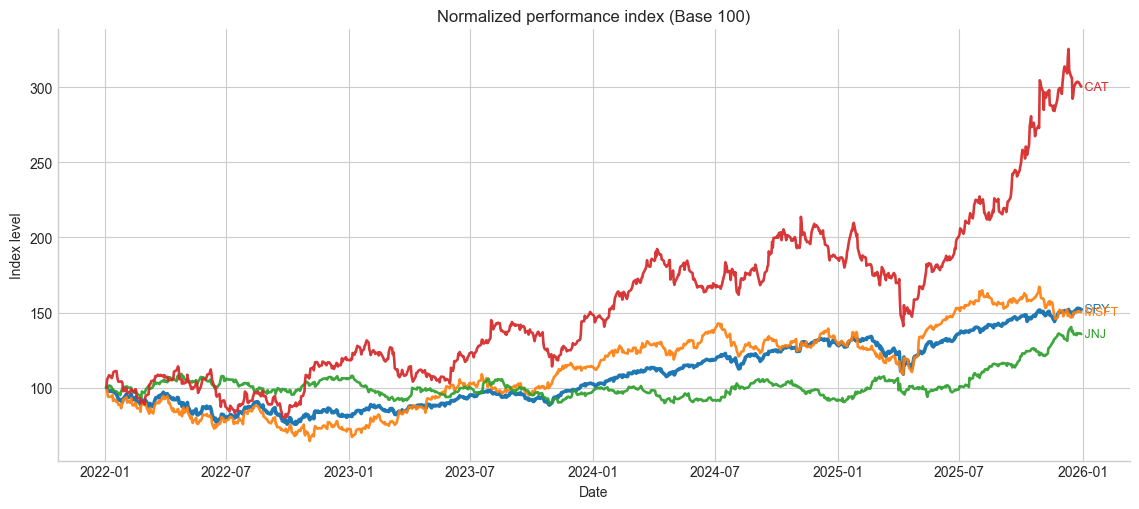

In [6]:
# Functional step: turn the canonical table into an interpretable cross-asset performance view.
# Financial purpose: base-100 performance is often the cleanest way to compare names with different absolute price levels.
# Create the figure for the normalized performance comparison.
fig, ax = plt.subplots(figsize=(11.5, 5.2))

# Plot each asset on the same base-100 scale.
for ticker in TICKERS:
    line_width = 2.6 if ticker == BENCHMARK else 1.9
    line_alpha = 1.0 if ticker == BENCHMARK else 0.92
    ax.plot(normalized_index.index, normalized_index[ticker], label=ticker, linewidth=line_width, alpha=line_alpha)

    # Label the last point directly so the chart remains readable even without a large legend.
    ax.text(
        normalized_index.index[-1],
        normalized_index[ticker].iloc[-1],
        f" {ticker}",
        color=ax.lines[-1].get_color(),
        va="center",
        fontsize=9,
    )

# Title and axis labels explain the financial meaning of the chart.
ax.set_title("Normalized performance index (Base 100)")
ax.set_ylabel("Index level")
ax.set_xlabel("Date")

# Apply the common visual cleanup used across notebook charts.
style_axes(ax)

# Tight layout avoids overlaps in the notebook output.
plt.tight_layout()

# Render the chart.
plt.show()


The normalized chart answers a fundamental market question: which assets created the most value over the window, and how smooth or unstable was that path?

The next set of charts shifts the discussion from absolute performance to risk behavior and benchmark dependence, which is where professional monitoring usually becomes more nuanced.
        


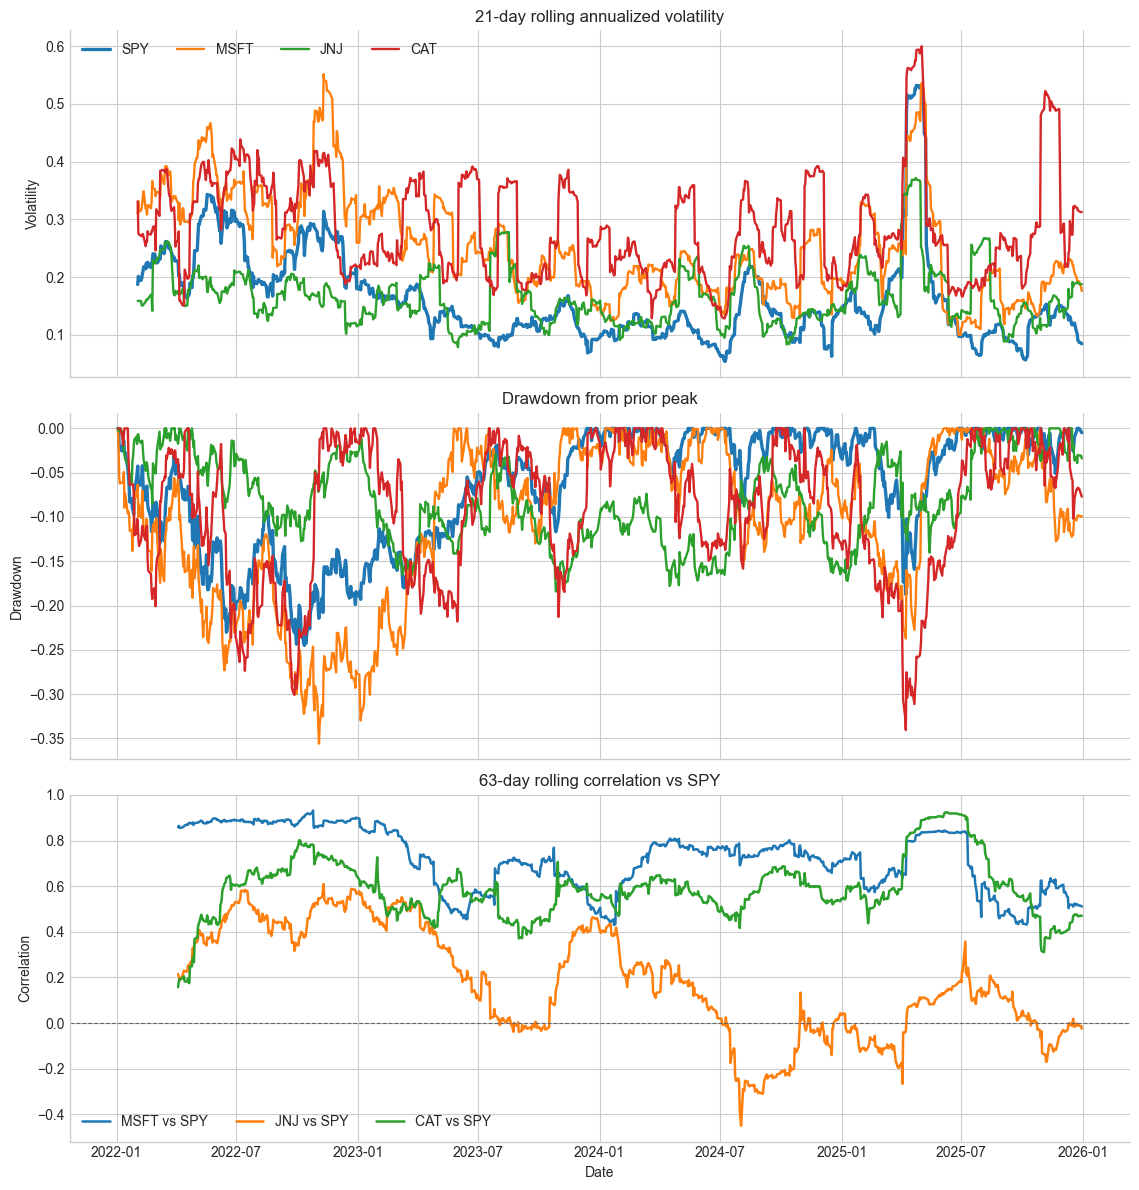

In [7]:
# Functional step: place volatility, drawdown, and benchmark dependence in one compact risk dashboard.
# Financial purpose: this is the point where price history becomes a monitoring tool rather than just a chart.
# Create a three-panel risk dashboard so performance and risk are read together.
fig, axes = plt.subplots(3, 1, figsize=(11.5, 12), sharex=True)

# Plot rolling volatility for each asset to compare short-term risk regimes.
for ticker in TICKERS:
    line_width = 2.4 if ticker == BENCHMARK else 1.7
    axes[0].plot(rolling_volatility_21d.index, rolling_volatility_21d[ticker], label=ticker, linewidth=line_width)

# Label the volatility panel.
axes[0].set_title("21-day rolling annualized volatility")
axes[0].set_ylabel("Volatility")
style_axes(axes[0])
axes[0].legend(frameon=False, ncol=4, loc="upper left")

# Plot drawdown for each asset to show peak-to-trough stress.
for ticker in TICKERS:
    line_width = 2.4 if ticker == BENCHMARK else 1.7
    axes[1].plot(drawdown.index, drawdown[ticker], label=ticker, linewidth=line_width)

# Label the drawdown panel.
axes[1].set_title("Drawdown from prior peak")
axes[1].set_ylabel("Drawdown")
style_axes(axes[1])

# Plot rolling correlation only for the non-benchmark assets.
for ticker in [ticker for ticker in TICKERS if ticker != BENCHMARK]:
    axes[2].plot(rolling_correlation_63d.index, rolling_correlation_63d[ticker], label=f"{ticker} vs {BENCHMARK}", linewidth=1.8)

# Add a zero line so changes in sign are easy to identify.
axes[2].axhline(0, color="#666666", linewidth=0.8, linestyle="--")

# Label the correlation panel.
axes[2].set_title(f"63-day rolling correlation vs {BENCHMARK}")
axes[2].set_ylabel("Correlation")
axes[2].set_xlabel("Date")
style_axes(axes[2])
axes[2].legend(frameon=False, ncol=3, loc="lower left")

# Tight layout keeps the three panels compact and readable.
plt.tight_layout()

# Render the full risk dashboard.
plt.show()


## I. Analyst summary table

**Financial purpose.** This is the hand-off point from data preparation to decision support.

A professional workflow should end with a compact output that can be reused in monitoring, reporting, or decision-making.

**What are we doing?** We aggregate the full analysis into one summary table by asset.

**Why does it matter?** Senior stakeholders rarely want the full raw dataset. They want a concise comparison across performance, risk, downside, and market linkage.

**What does this output allow us to do next?** It gives us a presentation-ready summary that can feed dashboards, peer reviews, screening workflows, or later notebooks in the course.

If the canonical table is the single source of truth, this summary table is the first real analyst-facing deliverable built on top of it.
        


In [8]:
# Functional step: condense the whole notebook into one analyst-facing comparison table.
# Financial purpose: this is the deliverable that a portfolio analyst, PM, or instructor can discuss quickly.
# Build the final analyst-facing summary table asset by asset.
summary_table = pd.DataFrame(index=TICKERS)

# Add total performance over the whole window.
summary_table["Cumulative return"] = normalized_index.iloc[-1] / 100 - 1

# Add annualized return so the assets can be compared on a yearly basis.
summary_table["Annualized return"] = annualized_return(daily_returns)

# Add annualized volatility as the standard risk measure for daily data.
summary_table["Annualized volatility"] = annualized_volatility(daily_returns)

# Add maximum drawdown to capture the worst observed peak-to-trough loss.
summary_table["Max drawdown"] = drawdown.min()

# Add full-sample correlation versus the benchmark.
summary_table[f"Correlation vs {BENCHMARK}"] = daily_returns.corr()[BENCHMARK]

# Create a new column for the latest rolling correlation reading.
summary_table[f"Latest 63d corr vs {BENCHMARK}"] = pd.Series(np.nan, index=TICKERS)

# Overwrite the non-benchmark rows with the actual latest rolling correlation values.
summary_table.loc[rolling_correlation_63d.columns, f"Latest 63d corr vs {BENCHMARK}"] = rolling_correlation_63d.iloc[-1]

# Sort the final summary by annualized return to make ranking intuitive.
summary_table = summary_table.sort_values("Annualized return", ascending=False)

# Create a display copy so formatting does not overwrite the underlying numeric table.
summary_display = summary_table.copy()

# Convert each metric to percentage format because that is how analysts usually read this table.
for column in summary_display.columns:
    summary_display[column] = summary_display[column].map(lambda value: pct(value) if pd.notna(value) else "--")

# Display the final presentation-ready summary table.
display(summary_display)

# Identify the best performer in cumulative return terms.
best_performer = summary_table["Cumulative return"].idxmax()

# Identify the asset with the highest annualized volatility.
highest_vol_asset = summary_table["Annualized volatility"].idxmax()

# Identify the asset with the worst maximum drawdown.
deepest_drawdown_asset = summary_table["Max drawdown"].idxmin()

# Identify the least benchmark-like asset among the non-benchmark names.
least_correlated_asset = summary_table[f"Correlation vs {BENCHMARK}"].drop(index=BENCHMARK).idxmin()

# Translate the table into a short analyst-style narrative.
display(
    Markdown(
        f"**Analyst read-out**\n\n"
        f"- `{best_performer}` delivered the strongest cumulative return across the period.\n"
        f"- `{highest_vol_asset}` carried the highest annualized volatility, so it came with the widest return dispersion.\n"
        f"- `{deepest_drawdown_asset}` experienced the deepest peak-to-trough loss.\n"
        f"- `{least_correlated_asset}` was the least correlated asset versus `{BENCHMARK}`, which is useful for diversification discussions."
    )
)


,Cumulative return,Annualized return,Annualized volatility,Max drawdown,Correlation vs SPY,Latest 63d corr vs SPY
CAT,200.48%,31.91%,30.18%,-34.05%,58.32%,47.01%
SPY,52.04%,11.12%,18.02%,-24.50%,100.00%,--
MSFT,50.50%,10.84%,26.79%,-35.58%,76.53%,51.10%
JNJ,35.61%,7.97%,17.26%,-18.41%,19.99%,-2.43%


**Analyst read-out**

- `CAT` delivered the strongest cumulative return across the period.
- `CAT` carried the highest annualized volatility, so it came with the widest return dispersion.
- `MSFT` experienced the deepest peak-to-trough loss.
- `JNJ` was the least correlated asset versus `SPY`, which is useful for diversification discussions.

## J. Final interpretation and downstream use

**Financial purpose.** The notebook should end by making clear what the dataset is now ready to support in real finance work.

At the start of the notebook, we had raw market data. By the end, we have a disciplined analytical dataset.

This dataset is now ready to support:

- market monitoring
- peer comparison
- dashboarding
- risk reporting
- signal research
- strategy prototyping

It also creates the right bridge to later work in the course:

- In later corporate finance work, the same discipline around clean inputs applies to modeling assumptions and output interpretation.
- In later trading work, the same canonical price table logic becomes the foundation for backtests, signals, and performance evaluation.

## Key takeaways

- Professional financial analysis starts with disciplined data treatment, not with isolated charts or formulas.
- A canonical price table is the single source of truth for downstream metrics.
- Returns, volatility, drawdown, and correlation are complementary views of the same market reality.
- The goal of Python in this session is not syntax mastery. It is to build a reliable market-data workflow that can support real financial work.
        
